# Gene CDS start

In [1]:
import sys
sys.path.append('..')
from ExonPTMapper import plot

plotter = plot.plotter()

Loading exon-specific data
Loading transcript-specific data
Loading gene-specific info
Loading unique protein isoforms
Loading protein-specific info
Loading information on PTMs on canonical proteins
Loading information on PTMs on canonical proteins


C:\Users\crowl\OneDrive\Documents\GradSchool\Research\Splicing\ExonPTMapper\ExonPTMapper\plot.py:833: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  self.ptm_coordinates = pd.read_csv(config.processed_data_dir + 'ptm_coordinates.csv',index_col = 0,


Loading information on PTMs on alternative proteins


In [5]:
plotter.exons

,Gene stable ID,Transcript stable ID,Exon stable ID,Constitutive exon,Exon rank in transcript,Exon Start (Gene),Exon End (Gene),Exon Sequence,Exon Length,Exon End (Transcript),Exon Start (Transcript),Exon Start (Protein),Exon End (Protein),Exon AA Seq (Ragged),Exon AA Seq (Full Codon),Exon Start (Gene Coding),Exon End (Gene Coding),Warnings (AA Seq)
0,ENSG00000004059,ENST00000000233,ENSE00001872691,0,1,127588411,127588565,CTGCTGCTGCTGCGCCCCATCCCCCCGCGGCCGGCCAGTTCCAGCC...,155,155,0,0.000000,22.333333,MGLTVSALFSRIFGKKQMRILM-V,MGLTVSALFSRIFGKKQMRILM,127588499.0,127588565.0,NaN
1,ENSG00000004059,ENST00000000233,ENSE00003494180,0,2,127589083,127589163,TTGGCTTGGATGCGGCTGGCAAGACCACAATCCTGTACAAACTGAA...,81,236,155,22.333333,49.333333,V-GLDAAGKTTILYKLKLGEIVTTIPTI-G,GLDAAGKTTILYKLKLGEIVTTIPTI,127589083.0,127589163.0,NaN
2,ENSG00000004059,ENST00000000233,ENSE00003504066,0,3,127589485,127589594,GCTTCAATGTAGAAACAGTGGAATATAAGAACATCTGTTTCACAGT...,110,346,236,49.333333,86.000000,G-FNVETVEYKNICFTVWDVGGQDKIRPLWRHYFQNTQ,FNVETVEYKNICFTVWDVGGQDKIRPLWRHYFQNTQ,127589485.0,127589594.0,NaN
3,ENSG00000004059,ENST00000000233,ENSE00003678978,0,4,127590066,127590137,GGCCTCATCTTTGTGGTGGACAGTAATGACCGGGAGCGGGTCCAAG...,72,418,346,86.000000,110.000000,GLIFVVDSNDRERVQESADELQKM,GLIFVVDSNDRERVQESADELQKM,127590066.0,127590137.0,NaN
4,ENSG00000004059,ENST00000000233,ENSE00003676786,0,5,127590963,127591088,CTGCAGGAGGACGAGCTGCGGGATGCAGTGCTGCTGGTATTTGCCA...,126,544,418,110.000000,152.000000,LQEDELRDAVLLVFANKQDMPNAMPVSELTDKLGLQHLRSRT,LQEDELRDAVLLVFANKQDMPNAMPVSELTDKLGLQHLRSRT,127590963.0,127591088.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850910,ENSG00000103275,ENST00000713921,ENSE00003608455,0,4,1314293,1314376,GGTTTCGTGGCTGTCCCAACAAAAAATCCCGATGGCACGATGAACC...,84,530,446,22.000000,50.000000,GFVAVPTKNPDGTMNLMNWECAIPGKKG,GFVAVPTKNPDGTMNLMNWECAIPGKKG,1314293.0,1314376.0,NaN
850911,ENSG00000103275,ENST00000713921,ENSE00000873575,0,5,1315654,1315726,ACTCCGTGGGAAGGAGGCTTGTTTAAACTACGGATGCTTTTCAAAG...,73,603,530,50.000000,74.333333,TPWEGGLFKLRMLFKDDYPSSPPK-C,TPWEGGLFKLRMLFKDDYPSSPPK,1315654.0,1315726.0,NaN
850912,ENSG00000103275,ENST00000713921,ENSE00003584681,0,6,1320174,1320283,GTAAATTCGAACCACCATTATTTCACCCGAATGTGTACCCTTCGGG...,110,713,603,74.333333,111.000000,C-KFEPPLFHPNVYPSGTVCLSILEEDKDWRPAITIKQ,KFEPPLFHPNVYPSGTVCLSILEEDKDWRPAITIKQ,1320174.0,1320283.0,NaN
850913,ENSG00000103275,ENST00000713921,ENSE00003788207,0,7,1320438,1320517,ATCCTATTAGGAATACAGGAACTTCTAAATGAACCAAATATCCAAG...,80,793,713,111.000000,137.666667,ILLGIQELLNEPNIQDPAQAEAYTIY-C,ILLGIQELLNEPNIQDPAQAEAYTIY,1320438.0,1320517.0,NaN


In [13]:
from tqdm import tqdm
import numpy as np

In [12]:
row

Gene stable ID                                                                  ENSG00000149527
Transcript length (including UTRs and CDS)                                               3781.0
APPRIS annotation                                                                           NaN
Ensembl Canonical                                                                           NaN
Transcript support level (TSL)                                                             tsl5
GENCODE basic annotation                                                                    NaN
Exon cuts                                     91,220,391,485,689,810,982,1090,1234,1327,1410...
Transcript Sequence                           GGCGCGCACCTGGGTCACTGGCCTGCGCTACCTCATGGCCGGCATC...
Coding Sequence                               NNGGCGCGCACCTGGGTCACTGGCCTGCGCTACCTCATGGCCGGCA...
Relative CDS Start (bp)                                                                     NaN
Relative CDS Stop (bp)                  

In [14]:
start_list = []
end_list = []
for i,row in tqdm(plotter.transcripts.iterrows(), total = plotter.transcripts.shape[0]):
    if row['Relative CDS Start (bp)'] == row['Relative CDS Start (bp)']:
        exons = plotter.exons[plotter.exons['Transcript stable ID'] == i]
        gene_stable_id = row['Gene stable ID'] 
        strand = plotter.genes.loc[gene_stable_id, 'Strand']
        gene_cds_start, gene_cds_end = plot.getGenomicCodingRegion(row, exons, strand = strand)
        start_list.append(gene_cds_start)
        end_list.append(gene_cds_end)
    else:
        start_list.append(np.nan)
        end_list.append(np.nan)
plotter.transcripts['Gene_CDS_start'] = gene_cds_start
plotter.transcripts['Gene_CDS_end'] = gene_cds_end


100%|██████████| 89110/89110 [50:17<00:00, 29.53it/s] 


In [18]:
ptms = plotter.get_ptm_info_for_gene(chromosome, strand, spliced_region)

AttributeError: 'plotter' object has no attribute 'get_ptm_info_for_gene'

In [15]:
from ExonPTMapper import config

In [16]:
plotter.transcripts.to_csv(config.processed_data_dir + 'transcripts.csv', index = True)

# Current plotting options

In [1]:
import sys
sys.path.append('..')
from ExonPTMapper import plot

plotter = plot.plotter()

Loading exon-specific data
Loading transcript-specific data
Loading gene-specific info
Loading unique protein isoforms
Loading protein-specific info
Loading information on PTMs on canonical proteins
Loading information on PTMs on canonical proteins


C:\Users\crowl\OneDrive\Documents\GradSchool\Research\Splicing\ExonPTMapper\ExonPTMapper\plot.py:833: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  self.ptm_coordinates = pd.read_csv(config.processed_data_dir + 'ptm_coordinates.csv',index_col = 0,


Loading information on PTMs on alternative proteins


In [2]:
plotter.transcripts[plotter.transcripts['Gene stable ID'] == 'ENSG00000103197'].head()

,Gene stable ID,Transcript length (including UTRs and CDS),APPRIS annotation,Ensembl Canonical,Transcript support level (TSL),GENCODE basic annotation,Exon cuts,Transcript Sequence,Coding Sequence,Relative CDS Start (bp),Relative CDS Stop (bp),Warnings,CCDS ID,TRIFID Score,Amino Acid Sequence,UniProt Isoform Type
Transcript stable ID,,,,,,,,,,,,,,,,
ENST00000643088,ENSG00000103197,5970.0,NaN,NaN,NaN,GENCODE basic,"89,256,343,454,599,717,766,892,966,1093,1237,1...",CGGGTCGCGCTTCCGGCGGCGTCCCGGGGCCAGGGGGGTGCGCCTT...,ATGGCCAAACCAACAAGCAAAGATTCAGGCTTGAAGGAGAAGTTTA...,118.0,5335.0,NaN,-,0.6593,MAKPTSKDSGLKEKFKILLGLGTPRPNPRSAEGKQTEFIITAEILR...,NaN
ENST00000643946,ENSG00000103197,6344.0,alternative2,NaN,NaN,GENCODE basic,"89,256,343,454,599,717,766,892,966,1093,1237,1...",CGGGTCGCGCTTCCGGCGGCGTCCCGGGGCCAGGGGGGTGCGCCTT...,ATGGCCAAACCAACAAGCAAAGATTCAGGCTTGAAGGAGAAGTTTA...,118.0,5467.0,NaN,-,0.7595,MAKPTSKDSGLKEKFKILLGLGTPRPNPRSAEGKQTEFIITAEILR...,NaN
ENST00000642206,ENSG00000103197,5485.0,NaN,NaN,NaN,GENCODE basic,"87,254,341,497,642,760,809,935,1009,1136,1280,...",GGTCGCGCTTCCGGCGGCGTCCCGGGGCCAGGGGGGTGCGCCTTTC...,ATGGCCAAACCAACAAGCAAAGATTCAGGCTTGAAGGAGAAGTTTA...,116.0,5387.0,NaN,-,0.1175,MAKPTSKDSGLKEKFKILLGLGTPRPNPRSAEGKQTEFIITAEILR...,NaN
ENST00000382538,ENSG00000103197,5264.0,NaN,NaN,tsl2,GENCODE basic,"86,173,284,429,547,596,722,796,923,1067,1205,1...",GTCGCGCTTCCGGCGGCGTCCCGGGGCCAGGGGGGTGCGCCTTTCT...,ATGGAATGTGGCCTCAACAATCGCATCCGGATGATAGGGCAGATTT...,95.0,5174.0,NaN,CCDS81934.1,0.5001,MECGLNNRIRMIGQICEVAKTKKFEEHAVEALWKAVADLLQPERPL...,Alternative
ENST00000219476,ENSG00000103197,6415.0,NaN,1.0,tsl5 (assigned to previous version 7),GENCODE basic,"81,248,335,446,591,709,758,884,958,1085,1229,1...",GCTTCCGGCGGCGTCCCGGGGCCAGGGGGGTGCGCCTTTCTCCGCG...,ATGGCCAAACCAACAAGCAAAGATTCAGGCTTGAAGGAGAAGTTTA...,110.0,5534.0,NaN,CCDS10458.1,0.7843,MAKPTSKDSGLKEKFKILLGLGTPRPNPRSAEGKQTEFIITAEILR...,Canonical


Transcripts with Missing/Conflicting Coding Information: ENST00000644399,ENST00000645186


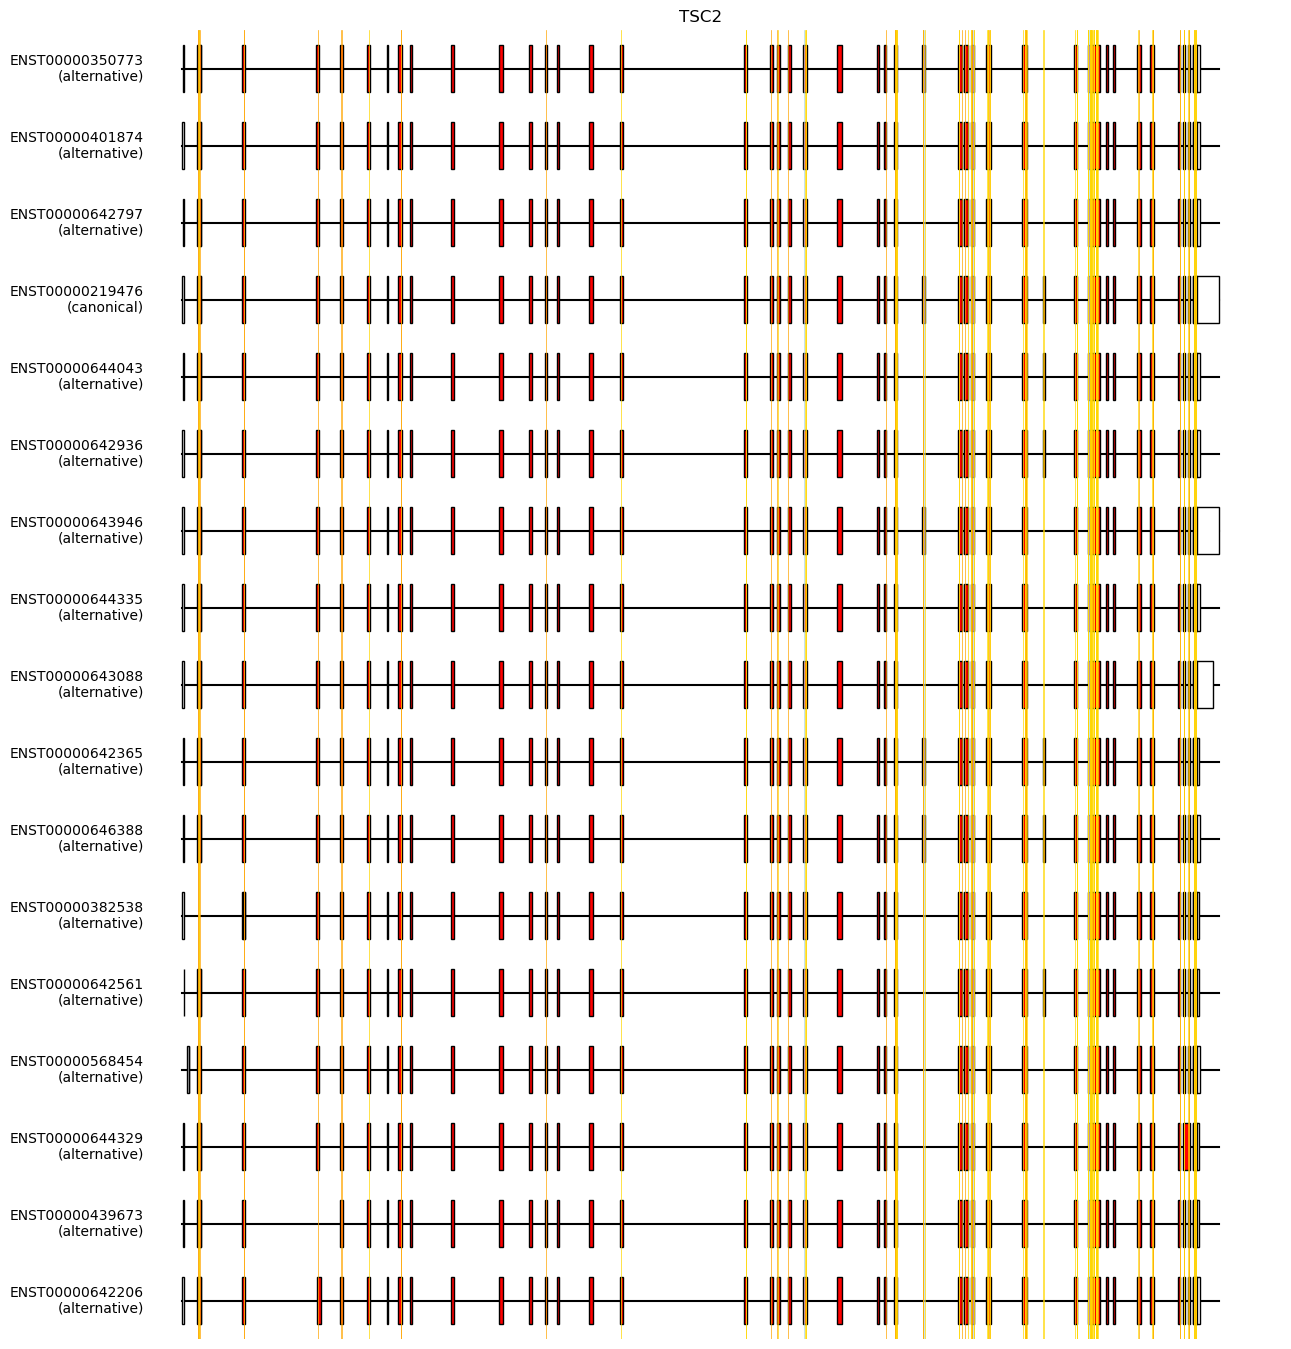

In [9]:
plotter.plotTranscripts('TSC2', add_ptms = True)

<Axes: title={'center': 'TSC2:ENST00000219476'}, xlabel='Protein Position (AA)'>

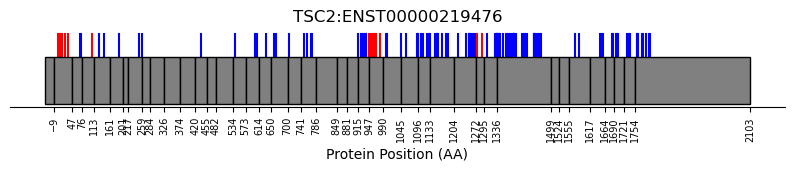

In [10]:
plotter.plotCanonical('TSC2')

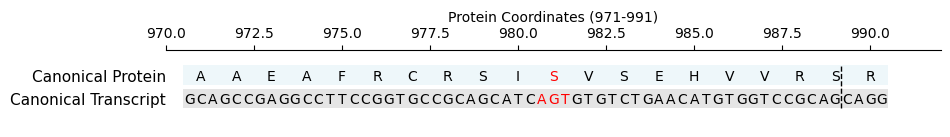

In [ ]:
plotter.plotSequenceAroundPTM('P49815-1_S981', transcript_id = 'ENST00000219476')

In [4]:
plotter.alternative_ptms.columns

Index(['Unnamed: 0', 'Gene stable ID', 'Alternative Transcript',
       'Chromosome/scaffold name', 'Strand', 'Source of PTM',
       'Canonical Residue', 'Modification', 'Modification Class', 'Ragged',
       'Genomic Coordinates', 'Second Exon', 'Frame', 'Alternative Residue',
       'Alternative Protein Position (AA)', 'Mapping Result',
       'Conserved Flank (Size = 5)', 'Exon ID (Canonical)',
       'Exon ID (Alternative)', 'Event Type', 'TRIFID Score',
       'Flanking Sequence', 'Tryptic Fragment'],
      dtype='object')

KeyError: 'Canonical Protein Location (AA)'

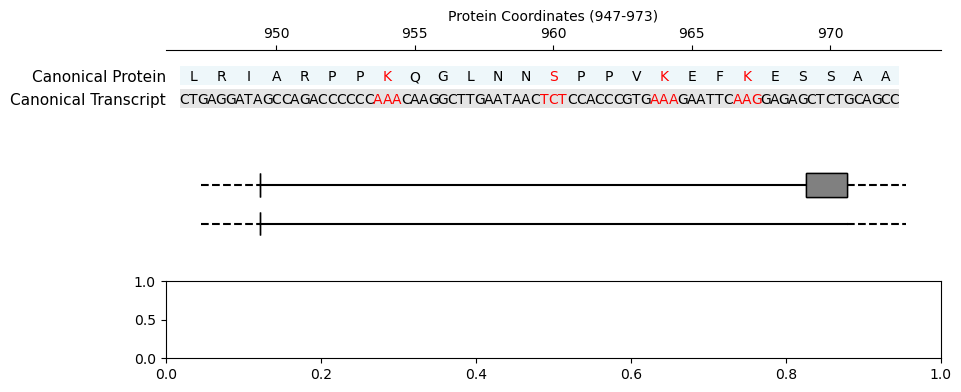

In [3]:
plotter.plotPTMChanges('P49815-1_S960', alternative_transcript_id = 'ENST00000382538')

# Mapper DB options

In [ ]:
import sys
sys.path.append('..')
import sql_interface
mapper_db = sql_interface.mapper_db('mapper.db')


In [1]:
import sqlite3
import plotting
import importlib
importlib.reload(plotting)

conn = sqlite3.connect('mapper.db')
plotter = plotting.plotter(conn)

## Plot canonical isoform

In [5]:
#plot canonical protein with domains
plotter.plot_canonical_isoform('EGFR')

[('P00533', 'Pkinase_Tyr', 712, 968, 'P00533', 'ENSG00000146648', 'EGFR', 'ENSG00000146648', 'EGFR', 1, '7', 55019017, 55211628, 1), ('P00533', 'Recep_L_domain', 57, 168, 'P00533', 'ENSG00000146648', 'EGFR', 'ENSG00000146648', 'EGFR', 1, '7', 55019017, 55211628, 1), ('P00533', 'Recep_L_domain', 361, 481, 'P00533', 'ENSG00000146648', 'EGFR', 'ENSG00000146648', 'EGFR', 1, '7', 55019017, 55211628, 1)]


## Plot transcripts

In [7]:
isoforms

['P06241-1 (Canonical)', 'P06241-2', 'P06241-3']

In [9]:
isoform_id.split(' ')[0]

'P06241-1'

In [10]:
transcripts

['ENST00000354650', 'ENST00000368667']

In [14]:
print("Let's visualize the protein (exons, PTMs, and domains)! Please pick an isoform to visualize:")
text_id = 'FYN'
id_type = "Name"
isoforms = plotter.get_isoform_ids(text_id, id_type)
canonical_isoform = plotter.get_canonical_isoform(text_id, id_type = id_type)

#append indicator which is canonical
isoforms = [i + " (Canonical)" if i == canonical_isoform else i for i in isoforms]
isoform_id = isoforms[0].split(' ')[0]

#output transcripts associated with isoform
transcripts = plotter.get_transcript_ids(isoform_id, id_type = 'Isoform')
print('Transcript IDs: ' + ', '.join(transcripts))

exons = plotter.get_exon_info(isoform_id, id_type = 'Isoform')
ptms = plotter.get_ptm_table(isoform_id, include_constitutive = True)
if isoform_id == canonical_isoform:
    domains = plotter.get_domain_info(isoform_id.split('-')[0], id_type = 'UniProt')
    #domains = None
else:
    domains = None

fig = plotting.plot_protein_info(exons, ptms, list(domains))
fig.show()

Let's visualize the protein (exons, PTMs, and domains)! Please pick an isoform to visualize:
Transcript IDs: ENST00000354650, ENST00000368667
test
test
test


In [13]:
domains

[('P06241', 'SH3_1', 88, 135),
 ('P06241', 'SH2', 149, 231),
 ('P06241', 'Pkinase_Tyr', 271, 520)]

In [4]:
plotter.plot_isoform('P06241-1', domains = domains)

test
test
test


In [4]:
for d in domains:
    print(d[3])

135
231
520
